In [2]:
import numpy as np

import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.patches import Rectangle

from scipy.optimize import curve_fit

import dexplore as dx 
import xarray as xr
import os
import sys
import glob
import re

sys.path.append(os.path.abspath("steele-lab-analysis-functions"))
import analysis_functions.core as af
from analysis_functions.users.pacome._format_data_xarray import format_data_xarray

from cavity_analysis import cavity_analysis
from cavity_theory import cavity_modes

model = af.ComplexCircle()

In [3]:
dx.refresh_bokeh()

Loading BokehJS ...

In [4]:
base_folder = '/home/jovyan/steelelab/measurement_data/4KDIY/Pacome/sweep_length'
base_folder = '/home/jovyan/BACKUP/Pacome/sweep_length'

Dropping dummy coordinate/dimension 0: "None"
New dimensions are: ['freq', 'length']


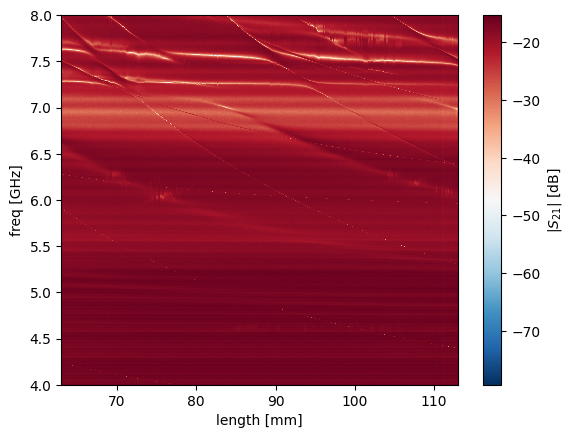

In [5]:
file_folder = '2026-06-23_08.25.35_0020_VNA_freqsweep_FFx'
full_path = base_folder + '/' + file_folder
h5_files = sorted(glob.glob(full_path + '/*.h5'))

data = xr.load_dataset(h5_files[0])

dx.interactive_linecut(data, initial_datavar=2)
dx.interactive_linecut_and_colormap(data)

translator = {'Frequency (Hz)':['freq', 'GHz', 1e9],
              'Cavity length (mm)':['length', 'mm', 1]}

data_absolute = format_data_xarray(data, tool='VNA', translator=translator)
data_absolute.mag.plot(cmap='RdBu_r')

In [10]:
data_absolute.isel(length=0, freq = data_absolute.freq.argmin('freq')).freq.values

array(4.)

In [13]:
data_absolute.isel(freq=0, length = data_absolute.length.argmax('length')).length.values

array(113.)

Dropping dummy coordinate/dimension 0: "None"
New dimensions are: ['freq', 'length']


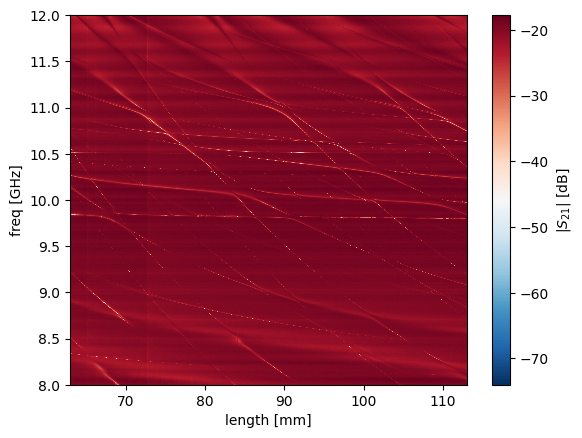

In [9]:
file_folder = '2026-06-22_16.35.28_0019_VNA_freqsweep_FFx'
full_path = base_folder + '/' + file_folder
h5_files = sorted(glob.glob(full_path + '/*.h5'))

data = xr.load_dataset(h5_files[0])

dx.interactive_linecut(data, initial_datavar=2)
dx.interactive_linecut_and_colormap(data)

translator = {'Frequency (Hz)':['freq', 'GHz', 1e9],
              'Cavity length (mm)':['length', 'mm', 1]}

data_absolute = format_data_xarray(data, tool='VNA', translator=translator)
data_absolute.mag.plot(cmap='RdBu_r')